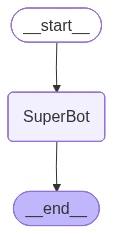

In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage,AIMessage,AnyMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]


import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def SuperBot(state:State):

    return {"messages":[llm.invoke(state['messages'])]}

builder = StateGraph(State)

builder.add_node('SuperBot',SuperBot)

builder.add_edge(START,'SuperBot')
builder.add_edge('SuperBot',END)

graph_memory = builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [7]:
config = {"configurable":{"thread_id":"1"}}

for chunk in graph_memory.stream({"messages":[HumanMessage(content="I am Harika and I like cricker")]},config=config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Harika! That's great to hear that you like cricket! It's such an exciting sport with a rich history. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 16, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'id': 'chatcmpl-DDCPu6qg519fT6I5xqhrBCzmxYcrW', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c95b7-a275-7eb0-bfc5-5504e47df31e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 32, 'total_tokens': 48, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_det

In [8]:
for chunk in graph_memory.stream({"messages":[HumanMessage(content="What is 2 plus 2")]},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='I am Harika and I like cricker', additional_kwargs={}, response_metadata={}, id='b3d60e62-0a6f-4e50-9105-0748040334b2'), AIMessage(content="Hi Harika! That's great to hear that you like cricket! It's such an exciting sport with a rich history. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 16, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'id': 'chatcmpl-DDCPu6qg519fT6I5xqhrBCzmxYcrW', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c95b7-a275-7eb0-bfc5-5504e47df31e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'i

In [9]:
for chunk in graph_memory.stream({"messages":[HumanMessage(content="who is sachin?")]},config=config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Sachin Tendulkar is a former Indian cricketer widely regarded as one of the greatest batsmen in the history of cricket. He made his debut for the Indian national team at the age of 16 and had a remarkable career that spanned 24 years, during which he set numerous records, including being the highest run-scorer in both Test and One Day International (ODI) cricket. Tendulkar is celebrated not only for his incredible skill and technique but also for his sportsmanship and contributions to the game. He received several awards and honors, including the Bharat Ratna, India's highest civilian award. Are you a fan of his?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 84, 'total_tokens': 216, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached

In [10]:
for chunk in graph_memory.stream({"messages":[HumanMessage(content="Explain me about olympaid exam")]},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='I am Harika and I like cricker', additional_kwargs={}, response_metadata={}, id='b3d60e62-0a6f-4e50-9105-0748040334b2'), AIMessage(content="Hi Harika! That's great to hear that you like cricket! It's such an exciting sport with a rich history. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 16, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'id': 'chatcmpl-DDCPu6qg519fT6I5xqhrBCzmxYcrW', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c95b7-a275-7eb0-bfc5-5504e47df31e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'i